[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


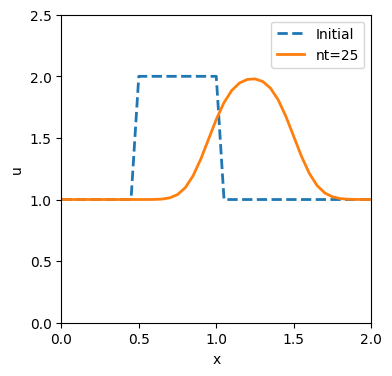

(t=0.0, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
(t=0.1, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
(t=0.2, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
(t=0.3, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

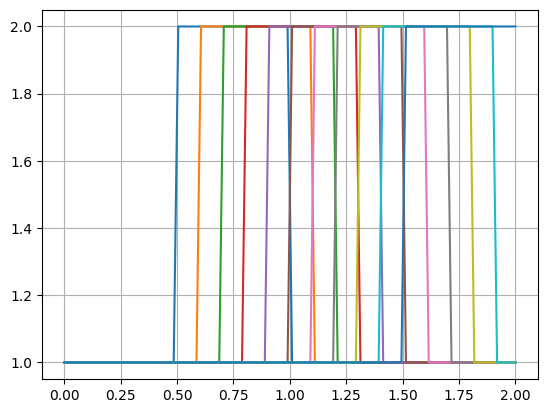

In [1]:
import numpy as np
import matplotlib.pyplot as plt


nx=41 # numero de divisiones en la grilla x
L=2.0 # tamanio total del espacio
dx= L/(nx-1) # salto en x
nt=25 # numero de pasos en el tiempo
dt=0.02 # salto en el tiempo
c=1.0 # velocidad de conveccion

x = np.linspace(0.0,L,num=nx)

u0 = np.ones(nx)
mask = np.where(np.logical_and(x>= 0.5, x<=1.0))
mask

u0[mask] = 2.0
print(u0)

u = u0.copy()
for n in range(1,nt):
    un = u.copy()
    for i in range(1,nx):
        u[i] = un[i] - c * dt/dx * (un[i] - un[i-1])


plt.figure(figsize=(4.0,4.0))
plt.xlabel('x')
plt.ylabel('u')
plt.plot(x,u0,label='Initial',color='C0', linestyle = '--', linewidth=2)
plt.plot(x,u,label='nt={}'.format(nt),color='C1',linestyle='-',linewidth=2)
plt.legend()
plt.xlim(0.0, L)
plt.ylim(0.0,2.5)

plt.show()



# Parámetros
c = 1.0              # velocidad
x = np.linspace(0, 2, 100)   # 100 puntos espaciales (ejemplo)
t_vals = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]  # tiempos a simular

# Condición
def onda_cuadrada(x):
    return np.where((x >= 0.5) & (x <= 1.0), 2, 1)

# Solución analítica discreta
def solucion(x, t, c):
    return onda_cuadrada(x - c*t)

# Simulación en varios tiempos
for t in t_vals:
    u = solucion(x, t, c)
    print(f"(t={t:.1f}, {u.tolist()})")
    plt.plot(x,u)

plt.grid()
plt.show()

# # La deformacion inicia con valores menores a 100 usando solo c








¿Qué hace la ecuación de advección lineal?

La ecuación: ∂u/∂t + c·∂u/∂x = 0 modela el transporte de una onda con velocidad constante c:

Toda la forma de la onda se mueve con la misma velocidad c

No hay deformación de la forma de la onda

La solución es: u(x,t) = u₀(x - ct)

Comportamiento Esperado:

t=0: Onda cuadrada inicial en posición original

t>0: La onda completa se desplaza hacia la derecha con velocidad c=1.0

La forma de la onda cuadrada debería mantenerse intacta

t=1.0: La onda debería estar completamente desplazada 1 unidad a la derecha

Por qué el esquema upwind funciona:

c > 0: La información viene siempre de la izquierda

Diferencia hacia atrás: u[i] - u[i-1] sigue la dirección del flujo

Estabilidad: λ = c·dt/dx ≈ 0.389 < 1, cumple condición CFL

Problemas Numéricos Observables:
Difusión numérica: La onda cuadrada se "difumina" con el tiempo

Dispersión numérica: Pequeñas oscilaciones pueden aparecer

Atenuación de amplitudes: Los bordes sharp se suavizan

La condición CFL:

λ = c·dt/dx ≤ 1 es necesaria para estabilidad. Aquí λ ≈ 0.389, lo que garantiza estabilidad pero aún produce difusión numérica significativa debido al esquema de primer orden.

El código muestra cómo un pulso cuadrado se transporta hacia la derecha mientras sufre difusión numérica, un efecto artificial del esquema de discretización que suaviza los bordes sharp de la onda.




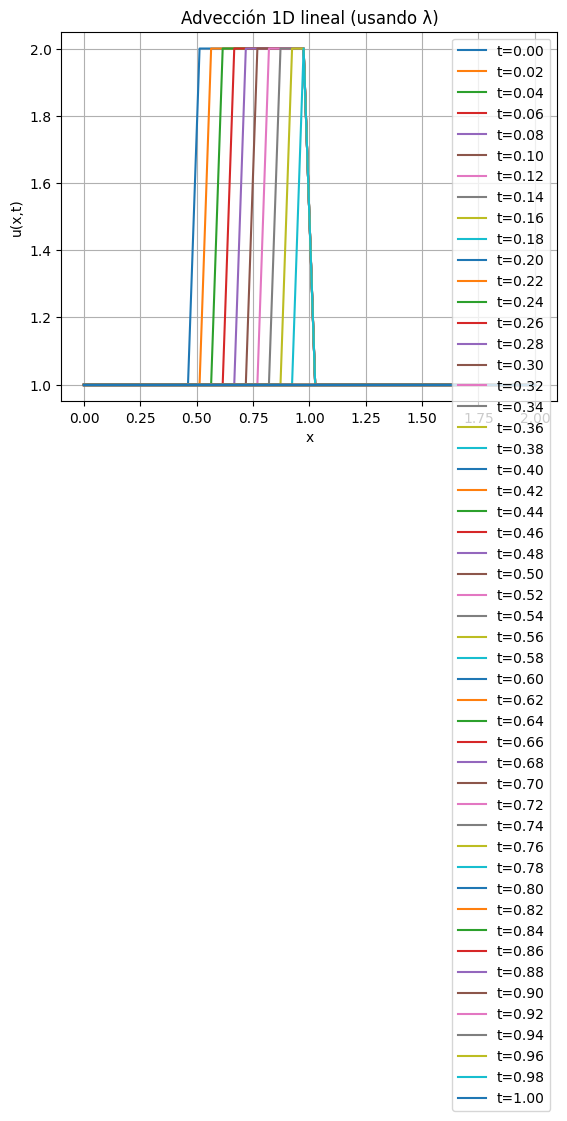

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
c = 1.0  # Velocidad de propagación de la onda
Nx = 40  # Número de puntos en el espacio
x = np.linspace(0, 2, Nx)  # Dominio espacial de 0 a 2
dx = x[1] - x[0]  # Tamaño del paso espacial (0.0513)
dt = 0.02  # Paso temporal
Nt = 50  # Número de pasos temporales
λ = c * dt / dx   # número de Courant (≈0.389)

# Condición inicial - una onda cuadrada
def onda_cuadrada(x):
    # Función que vale 2.0 entre 0.5 y 1.0, y 1.0 en el resto
    return np.where((x >= 0.5) & (x <= 1.0), 2, 1)

u = onda_cuadrada(x)  # Condición inicial en t=0
resultados_lambda = [(0, u.copy())]  # Almacenar resultados (tiempo, solución)

# Evolución temporal usando esquema upwind
for n in range(1, Nt+1):
    u_new = u.copy()  # Crear nueva solución basada en la actual
    u_new[0] = u[0]  # Condición de frontera izquierda (fija)

    # Esquema upwind explícito para advección lineal
    for i in range(1, Nx):  # Iterar sobre todos los puntos excepto el primero
        # Fórmula upwind: u_i^{n+1} = u_i^n - λ*(u_i^n - u_{i-1}^n)
        u_new[i] = u[i] - λ * (u[i] - u[i-1])

    u = u_new  # Actualizar la solución para el siguiente paso
    resultados_lambda.append((n*dt, u.copy()))  # Guardar resultado

# Graficar TODAS las curvas
plt.figure()
for t, u in resultados_lambda:   # Iterar sobre todos los tiempos guardados
    plt.plot(x, u, label=f"t={t:.2f}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.legend()
plt.title("Advección 1D lineal (usando λ)")
plt.grid()
plt.show()

¿Qué hace la ecuación de Burgers?

La ecuación de Burgers: ∂u/∂t + u·∂u/∂x = 0 modela ondas no lineales donde:

Partes más altas (u grande) se mueven más rápido

Partes más bajas (u pequeño) se mueven más lento

Esto causa deformación no lineal y eventual formación de choques

Comportamiento Esperado:

t=0: Onda cuadrada inicial (2.0 entre 0.5-1.0, 1.0 en el resto)

t pequeño: La parte alta (2.0) se mueve más rápido que la baja (1.0)

t medio: La parte frontal se empina (gradiente más pronunciado)

t grande: Se forma un choque (discontinuidad) donde las características se cruzan

Por qué el esquema upwind funciona:

u ≥ 0: La información viene de la izquierda → diferencia hacia atrás

u < 0: La información viene de la derecha → diferencia hacia adelante

Esto respeta la dirección del flujo de información

La condición CFL (Courant-Friedrichs-Lewy):

dt ≤ CFL·dx/u_max garantiza que la información no viaje más de una celda por paso temporal, evitando inestabilidades numéricas.

El código muestra cómo una onda no lineal se deforma y eventualmente forma un choque, con el esquema upwind capturando correctamente este comportamiento físico.

dx = 0.0202, u_max = 2.00, dt = 0.005051


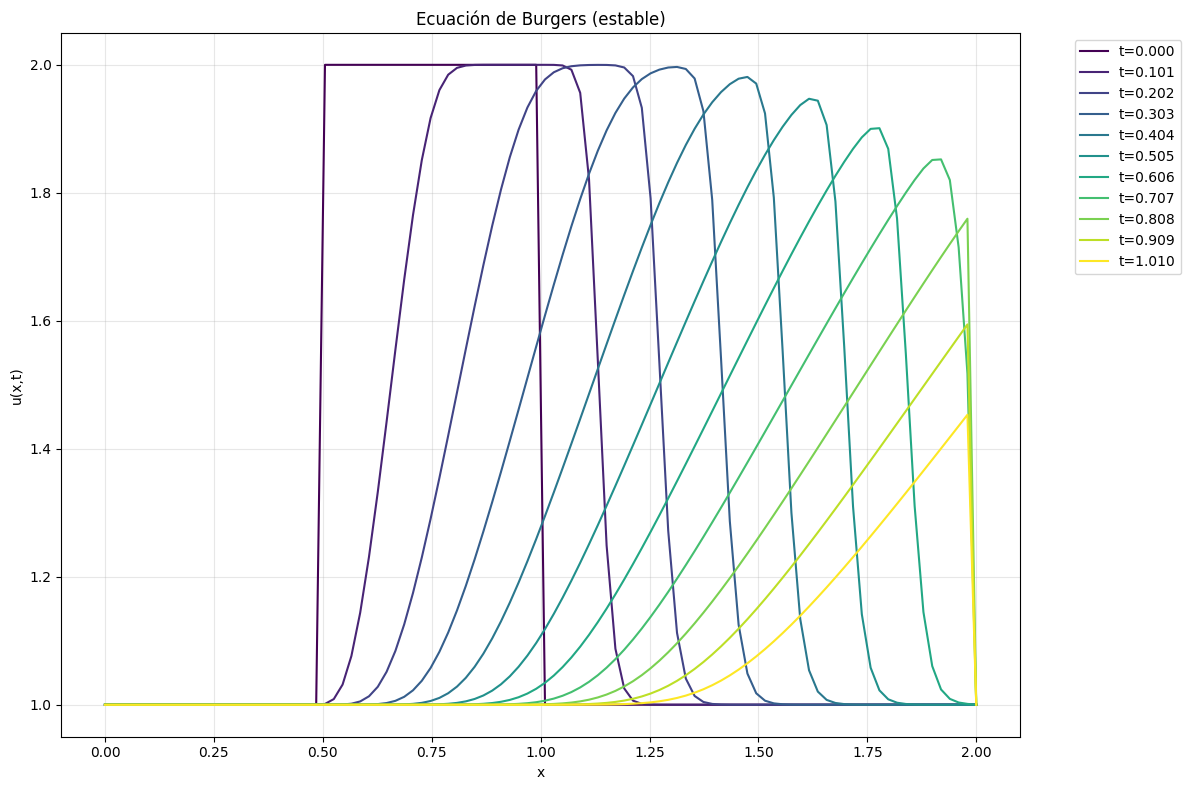

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros corregidos
Nx = 100  # Número de puntos en el espacio
x = np.linspace(0, 2, Nx)  # Dominio espacial de 0 a 2
dx = x[1] - x[0]  # Tamaño del paso espacial

# Condición inicial - una onda cuadrada
def onda_cuadrada(x):
    # Función que vale 2.0 entre 0.5 y 1.0, y 1.0 en el resto
    return np.where((x >= 0.5) & (x <= 1.0), 2.0, 1.0)

u0 = onda_cuadrada(x)  # Condición inicial en t=0

# Calcular dt basado en la condición CFL para Burgers
u_max = np.max(np.abs(u0))  # Velocidad máxima inicial
CFL = 0.5  # Número de Courant más conservador para no lineal
dt = CFL * dx / u_max  # Paso temporal que garantiza estabilidad

print(f"dx = {dx:.4f}, u_max = {u_max:.2f}, dt = {dt:.6f}")

# Configuración temporal
Nt = 200  # Número de pasos temporales
resultados_burgers = [(0, u0.copy())]  # Almacenar resultados (tiempo, solución)
u = u0.copy()  # Copia de la solución actual

# Evolución temporal estable usando esquema upwind
for n in range(1, Nt + 1):
    u_new = u.copy()  # Crear nueva solución basada en la actual

    # Esquema upwind condicional para Burgers (no lineal)
    for i in range(1, Nx - 1):  # Iterar sobre puntos internos
        if u[i] >= 0:
            # Cuando u es positivo: usar diferencia hacia atrás
            # La información viene de la izquierda
            u_new[i] = u[i] - (dt/dx) * u[i] * (u[i] - u[i-1])
        else:
            # Cuando u es negativo: usar diferencia hacia adelante
            # La información viene de la derecha
            u_new[i] = u[i] - (dt/dx) * u[i] * (u[i+1] - u[i])

    # Condiciones de frontera de Dirichlet (valores fijos)
    u_new[0] = u[0]    # Frontera izquierda fija
    u_new[-1] = u[-1]  # Frontera derecha fija

    u = u_new  # Actualizar la solución para el siguiente paso

    # Guardar resultados cada 20 pasos temporales
    if n % 20 == 0:
        resultados_burgers.append((n*dt, u.copy()))

# Graficar los resultados
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(resultados_burgers)))

# Plotear cada solución guardada con color diferente
for idx, (tiempo, solucion) in enumerate(resultados_burgers):
    plt.plot(x, solucion, color=colors[idx], label=f"t={tiempo:.3f}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Ecuación de Burgers (estable)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()